In [2]:
import jax.numpy as jnp
from jax import random
import jax
from flax.training import train_state
import optax
from flax import linen as nn
from tqdm.notebook import tqdm
# Optionally, you can save the losses to a file or plot them
import matplotlib.pyplot as plt
import numpy as np
import sys


In [3]:
# Model
class NNFunc(nn.Module):
    alpha: float
    eps: float = 0.25
    D: int = 100
    N: int = 500

    def setup(self):
        # This initialization didn't work hmmm 
        # self.W = self.param('W', nn.initializers.normal(), (self.N,self.D))
        self.W = self.param('W', random.normal, (self.N,self.D))

    def __call__(self, X):
        h = jnp.dot(self.W, X) / jnp.sqrt(self.D)
        f = self.alpha * jnp.mean(
            h + 0.5 * self.eps * h**2, axis=0
        )
        return f

In [4]:
# Create data
D = 100
P = 450
N = 500

X = random.normal(random.PRNGKey(0), (D,P))
Xt = random.normal(random.PRNGKey(1), (D,1000))
beta = random.normal(random.PRNGKey(2), (D,))

def target_fn(beta, X):
    return (X.T @ beta / jnp.sqrt(D))**2

y = target_fn(beta, X)
yt = target_fn(beta,Xt)



In [5]:
# Optimizer
eta = 0.5 * N
# eta = 5e-2 * N
tx = optax.sgd(learning_rate=eta)



  0%|          | 0/1000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.4610626697540283 | test loss: 3.5252585411071777 
 t: 998 | train loss: 0.004015977494418621 | test loss: 0.307576149702072143

  0%|          | 0/1000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.437218427658081 | test loss: 3.5246596336364746 
 t: 998 | train loss: 0.003430198412388563 | test loss: 0.360012412071228334

  0%|          | 0/1000 [00:00<?, ?it/s]

...

 t: 0 | train loss: 3.3349781036376953 | test loss: 3.4931435585021973 
 t: 998 | train loss: 5.04182607983239e-05 | test loss: 1.085483074188232465

  0%|          | 0/1000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.4085471630096436 | test loss: 3.50053071975708 
 t: 998 | train loss: 3.6617602745536715e-06 | test loss: 1.5415335893630981

  0%|          | 0/1000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.4579601287841797 | test loss: 3.5172998905181885 
 t: 998 | train loss: 0.000945317093282938 | test loss: 1.9732244014739990.125
0.25
0.5
1.0
2.0
4.0
8.0


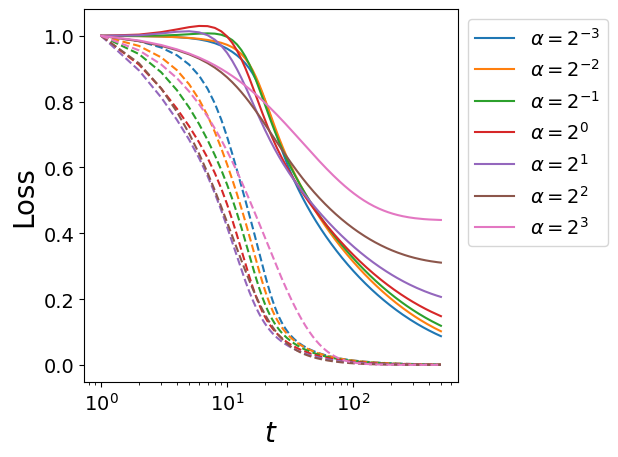

In [11]:
# alphas = [2**(-5),0.25,0.5,1.0,2.0,4.0,8.0,16,32]
alphas = [.125,.25,0.5,1.0,2.0,4.0,8.0,16.0]
# alphas = [2**(-5),0.25]
# alphas = [1.0, 2.0, 4.0]

all_tr_losses = []
all_te_losses = []


for alpha in alphas: 
    # Make model 
    # Initialize the model
    model = NNFunc(alpha=alpha, eps=0.25, D=D, N=N)
    params = model.init(jax.random.PRNGKey(1), X)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

    # Save intiializer 
    init_params = state.params

    @jax.jit
    def loss_fn(params, x, y):
        loss = jnp.mean(
            (state.apply_fn(params, x) - state.apply_fn(init_params, x) - y) ** 2 / alpha**2
        )
        return loss

    @jax.jit
    def train_step(state):
        loss, grads = jax.value_and_grad(loss_fn)(state.params, X, y)

        lamb = 1e-1 / alpha
        _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, X), (state.params,), (grads,))
        jacobian_fn = jax.jacrev(
            lambda params, x: state.apply_fn(params, x)
        )(state.params, X)
        flat_jacobian = []
        for layer in jacobian_fn['params'].values():
            flat_jacobian.append(layer.reshape(450, -1))
        jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
        mat = jacobian_fn @ jacobian_fn.T

        out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
        _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, X)
        adjustment = vjp_fn(out)[0] 
        grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)

        state = state.apply_gradients(grads=grads)
        return state, loss

    tr_losses = []
    te_losses = []
    for t in tqdm(range(1000)):
        state, loss = train_step(state)
        
        if t % 2 == 0:
            train_loss = alpha**2*loss_fn(state.params, X, y)
            test_loss = alpha**2*loss_fn(state.params, Xt, yt)
            tr_losses += [train_loss]
            te_losses += [test_loss]
            sys.stdout.write(f'\r t: {t} | train loss: {train_loss} | test loss: {test_loss}')

        if t % 10000 == 0:
            print(" ")

    all_tr_losses += [tr_losses]
    all_te_losses += [te_losses]
    
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

plt.xscale('log')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()




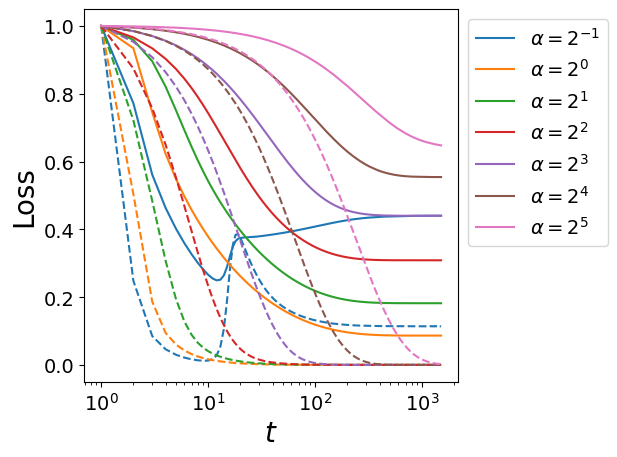

In [14]:
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,alpha in enumerate(alphas[:]):
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

plt.xscale('log')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



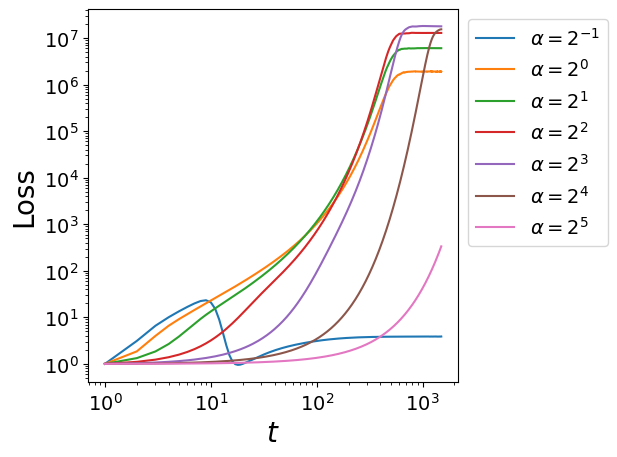

In [24]:
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,alpha in enumerate(alphas[:]):
    # plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    # plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

    plt.loglog(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), 
             (jnp.array(all_te_losses[i]) / all_te_losses[i][0]) / (jnp.array(all_tr_losses[i]) / all_tr_losses[i][0]) ,  
             color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha)
    )

plt.xscale('log')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

